# Gauge-aware divergence and curl at every HEALPix scale

This notebook validates `HealPixDivCurl` with analytic gradient and solid-body rotation fields, then applies `HealPixMultiScaleDivCurl` to a masked `HealPixDecomp` pyramid. Input channel zero is eastward velocity `u`; channel one is northward velocity `v`.

In [1]:
import healpix_geo
import matplotlib.pyplot as plt
import numpy as np
import torch

from healpix_analyse import (
    HealPixDecomp,
    HealPixDivCurl,
    HealPixMultiScaleDivCurl,
)

torch.manual_seed(3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
RADIUS_M = 6_371_008.8
print("device:", device)

device: cuda


## Partial domain

get data position from coastal domain, and check with global data using spherical harmonic.

In [8]:
import fsspec
import xarray as xr
fs = fsspec.filesystem("http")
ds=xr.open_zarr('https://data-taos.ifremer.fr/EGU25_CFOSAT/MARS_SST_EX.zarr')
ds

<xarray.Dataset> Size: 90MB
Dimensions:    (time: 24, depth: 8, latitude: 180, longitude: 324)
Coordinates:
  * time       (time) datetime64[ns] 192B 2025-03-20 ... 2025-03-20T23:00:00
  * depth      (depth) float32 32B 0.494 1.541 2.646 3.819 ... 6.441 7.93 9.573
  * latitude   (latitude) float32 720B 46.03 46.05 46.08 ... 50.94 50.97 51.0
  * longitude  (longitude) float32 1kB -7.999 -7.971 -7.944 ... 0.9456 0.9733
Data variables:
    thetao     (time, depth, latitude, longitude) float64 90MB dask.array<chunksize=(1, 1, 180, 324), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.8
    comment:      
    contact:      https://marine.copernicus.eu/contact
    institution:  NOW Systems (Spain)
    references:   http://marine.copernicus.eu/
    source:       NEMO3.6
    title:        Ocean 3D hourly mean fields for the Iberia-Biscay-Ireland (...

In [9]:
from healpix_resample import PSFResampler

# Define the HEALPix resolution
LEVEL = 11
data = ds.thetao.compute().values[12,0,:,:].astype('float64')
lon = np.tile(ds.longitude.compute().values,data.shape[0]).astype('float64')
lat = np.repeat(ds.latitude.compute().values,data.shape[1]).astype('float64')
data =data.flatten()

lon=lon[np.isfinite(data)]
lat=lat[np.isfinite(data)]
data=data[np.isfinite(data)]

resampler = PSFResampler(
    lon_deg=lon, 
    lat_deg=lat,
    level=LEVEL, 
    threshold=0.1, 
    verbose=True,
    device=device,
)

res = resampler.resample(data, lam=0.01, max_iter=30)

[PSFResampler] area not provided: auto-estimated from shared-latitude-ring grid structure.
Itt 0 : 6.088e+09
Itt 4 : 4.18e+07
Itt 8 : 6.128e+07
Itt 12 : 2.068e+06
Itt 16 : 3.381e+05
Itt 20 : 1.005e+05
Itt 24 : 1.059e+04
Itt 28 : 1929
Final Itt 29 : 1296


/home/jovyan/healpix-resample/healpix_resample/psf.py:600: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1780240370028/work/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  self.MT = MT_coo.to_sparse_csr()


<Axes: xlabel='Longitude (deg)', ylabel='Latitude (deg)'>

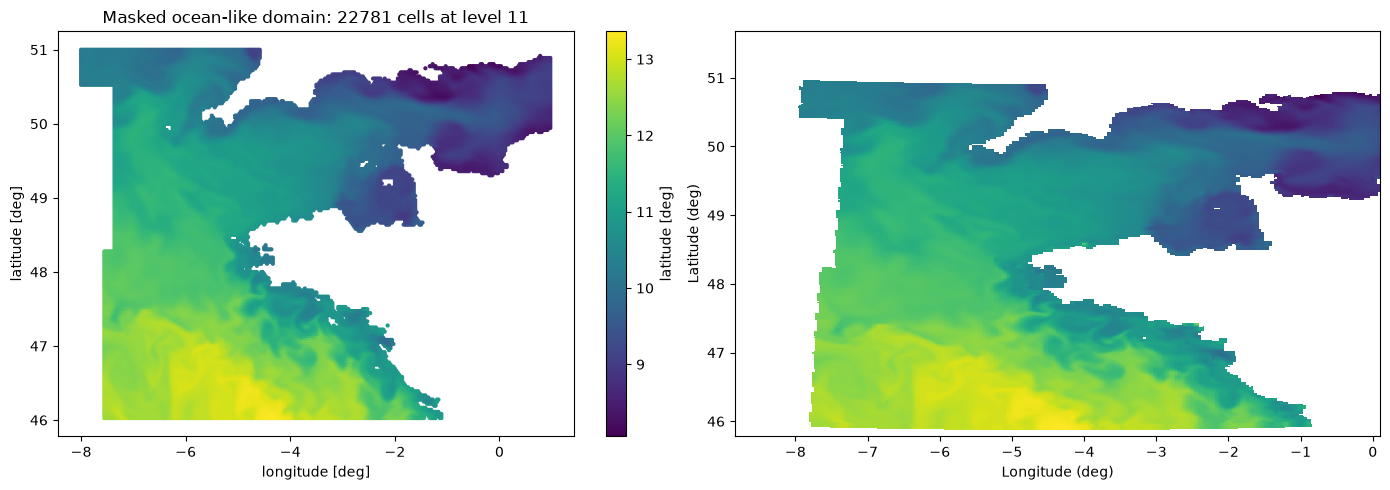

In [12]:
from foscat.Plot import lgnomproject

cell_ids=res.cell_ids
velocity = res.cell_data

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
plt.scatter(lon, lat, c=data, s=4, cmap="viridis")
plt.xlabel("longitude [deg]")
plt.ylabel("latitude [deg]")
plt.title(f"Masked ocean-like domain: {len(res.cell_ids)} cells at level {LEVEL}")
plt.colorbar(label="latitude [deg]")
plt.tight_layout()
lgnomproject(res.cell_ids,res.cell_data, 2**LEVEL,hold=False,sub=(1,2,2),interp=True)

# work in global 

In [13]:
#!/usr/bin/env python
import xarray as xr

try:
    dsG = xr.open_dataset("outputGT10m.grib")
except:
    c = cdsapi.Client()
    
    c.retrieve("reanalysis-era5-complete", {
        "class": "ea",
        "date": "2025-01-01",
        "expver": "1",
        "levtype": "sfc",
        "number": "0/1/2/3/4/5/6/7/8/9",
        "param": "165.128/166.128", #u,v at 10m
        "step": "12",
        "stream": "enda",
        "time": "09:00:00",
        "type": "4v",
        "grid":"N256",
    }, "outputGT10m.grib")
    dsG = xr.open_dataset("outputGT10m.grib")

dsG

/srv/conda/envs/notebook/lib/python3.13/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
Ignoring index file 'outputGT10m.grib.5b7b6.idx' older than GRIB file


<xarray.Dataset> Size: 47MB
Dimensions:     (number: 10, values: 348528)
Coordinates:
  * number      (number) int64 80B 0 1 2 3 4 5 6 7 8 9
    latitude    (values) float64 3MB ...
    longitude   (values) float64 3MB ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Dimensions without coordinates: values
Data variables:
    u10         (number, values) float32 14MB ...
    v10         (number, values) float32 14MB ...
    sst         (number, values) float32 14MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-04T07:15 GRIB to CDM+CF via cfgrib-0.9.1...

# convert ERA5 data into healpix using ALM

In [21]:
from healpix_analyse.alm_latlon import build_rings_from_latlon,map2alm_latlon
from healpix_analyse.healpix_sht import HEALPixSHT

ring_theta, ring_phi_list, ring_counts, idx = build_rings_from_latlon(np.deg2rad(90.0-dsG.latitude.values),
                         np.deg2rad(dsG.longitude.values))
ilevel=8
nside_out=2**ilevel # keep small to get rapid results

almu = map2alm_latlon(torch.tensor(dsG.u10.values[0,idx],device='cuda:0'),
                    ring_theta, ring_phi_list, ring_counts,quadrature='gauss_legendre',lmax=nside_out*3-1)
almv = map2alm_latlon(torch.tensor(dsG.v10.values[0,idx],device='cuda:0'),
                    ring_theta, ring_phi_list, ring_counts,quadrature='gauss_legendre',lmax=nside_out*3-1)

In [22]:
sht = HEALPixSHT(level=int(np.log2(nside_out)))

imu = sht.alm2map(almu)
imv = sht.alm2map(almv)

# comput div,curl from u,v field

In [ ]:
div, curl = sht.uv_to_curl_div(imu, imv)

In [ ]:
from healpix_plot.mollview import mollview

plt.figure(figsize=(16,10))
mollview(imu.cpu().numpy(),cmap='coolwarm',title=str(dsG.time.values)+' u10',hold=False,sub=(2,2,1))
mollview(imv.cpu().numpy(),cmap='coolwarm',title=str(dsG.time.values)+' v10',hold=False,sub=(2,2,2))
mollview(div.cpu().numpy(),cmap='coolwarm',title=str(dsG.time.values)+' div',hold=False,sub=(2,2,3))
mollview(curl.cpu().numpy(),cmap='coolwarm',title=str(dsG.time.values)+' curl',hold=False,sub=(2,2,4))

# resample data into coastal coordinate

In [20]:
from healpix_analyse.up  import HealPixUp

up_op=HealPixUp(level=ilevel,ellipsoid='sphere',cell_ids=cell_ids//(4**)


KeyboardInterrupt: 

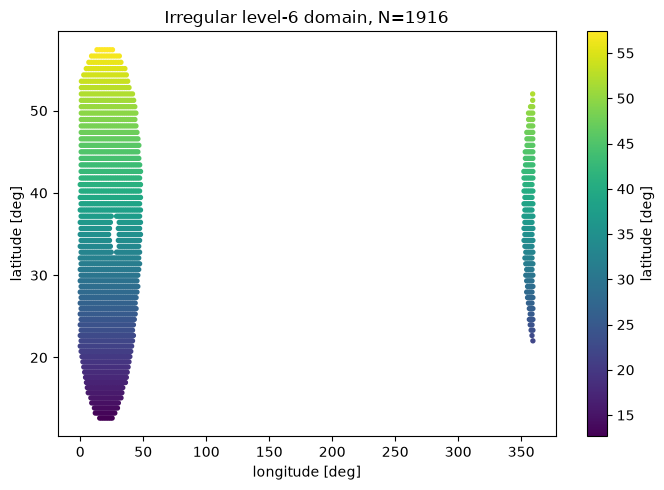

In [2]:
LEVEL = 6
CENTRE = (20.0, 35.0)
OUTER_RADIUS_DEG = 22.0
candidate_ids, _, _ = healpix_geo.nested.cone_coverage(
    CENTRE, OUTER_RADIUS_DEG, LEVEL, ellipsoid="sphere"
)
candidate_ids = np.asarray(candidate_ids, dtype=np.int64)
candidate_lon, candidate_lat = healpix_geo.nested.healpix_to_lonlat(
    candidate_ids.tolist(), LEVEL, ellipsoid="sphere"
)
candidate_lon = np.asarray(candidate_lon)
candidate_lat = np.asarray(candidate_lat)
island = ((candidate_lon - 27.0) / 3.2) ** 2 + ((candidate_lat - 35.0) / 2.5) ** 2 < 1.0
cell_ids = candidate_ids[~island]
lon, lat = healpix_geo.nested.healpix_to_lonlat(
    cell_ids.tolist(), LEVEL, ellipsoid="sphere"
)
lon = np.asarray(lon, dtype=np.float64)
lat = np.asarray(lat, dtype=np.float64)

plt.figure(figsize=(7, 5))
plt.scatter(lon, lat, c=lat, s=8, cmap="viridis")
plt.xlabel("longitude [deg]")
plt.ylabel("latitude [deg]")
plt.title(f"Irregular level-{LEVEL} domain, N={len(cell_ids)}")
plt.colorbar(label="latitude [deg]")
plt.tight_layout()

## Analytic tangent-vector fields

For a constant unit vector `A` and surface normal `n`, the tangent gradient field `U(A-(A.n)n)` has analytic divergence `-2U(A.n)/R` and zero curl. The solid-body rotation `U(A x n)` has zero divergence and curl `2U(A.n)/R`.

In [3]:
lon_rad = np.deg2rad(lon)
lat_rad = np.deg2rad(lat)
normal = np.stack((
    np.cos(lat_rad) * np.cos(lon_rad),
    np.cos(lat_rad) * np.sin(lon_rad),
    np.sin(lat_rad),
), axis=1)
east = np.stack((-np.sin(lon_rad), np.cos(lon_rad), np.zeros_like(lon_rad)), axis=1)
north = np.stack((
    -np.sin(lat_rad) * np.cos(lon_rad),
    -np.sin(lat_rad) * np.sin(lon_rad),
    np.cos(lat_rad),
), axis=1)
axis = np.array([0.3, -0.4, 0.8660254])
axis /= np.linalg.norm(axis)
speed = 0.5  # m/s
axis_dot_normal = normal @ axis

gradient_vector = speed * (axis[None, :] - axis_dot_normal[:, None] * normal)
rotation_vector = speed * np.cross(axis[None, :], normal)
gradient_uv = np.stack((
    np.sum(gradient_vector * east, axis=1),
    np.sum(gradient_vector * north, axis=1),
), axis=0)
rotation_uv = np.stack((
    np.sum(rotation_vector * east, axis=1),
    np.sum(rotation_vector * north, axis=1),
), axis=0)
truth_gradient = np.stack((-2.0 * speed * axis_dot_normal / RADIUS_M, np.zeros(len(cell_ids))))
truth_rotation = np.stack((np.zeros(len(cell_ids)), 2.0 * speed * axis_dot_normal / RADIUS_M))

## Single-scale convolution test

Two rotated gauges are retained separately. Their mean is compared with the analytic solution away from the outer boundary and artificial island.

In [4]:
layer = HealPixDivCurl(
    level=LEVEL,
    cell_ids=cell_ids,
    kernel_sz=5,
    sigma_pix=1.3,
    n_gauges=2,
    gauge_type="phi",
    gauge_reduce="none",
    ellipsoid="sphere",
    dtype=dtype,
    device=device,
)
gradient_estimates = layer(torch.as_tensor(gradient_uv, dtype=dtype, device=device))
rotation_estimates = layer(torch.as_tensor(rotation_uv, dtype=dtype, device=device))
gradient_mean = gradient_estimates.mean(dim=0).detach().cpu().numpy()
rotation_mean = rotation_estimates.mean(dim=0).detach().cpu().numpy()

def angular_distance_deg(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.deg2rad, (lon1, lat1, lon2, lat2))
    value = np.sin(lat1) * np.sin(lat2) + np.cos(lat1) * np.cos(lat2) * np.cos(lon1 - lon2)
    return np.rad2deg(np.arccos(np.clip(value, -1.0, 1.0)))

distance_from_centre = angular_distance_deg(lon, lat, *CENTRE)
distance_from_island = angular_distance_deg(lon, lat, 27.0, 35.0)
valid = (distance_from_centre < 17.0) & (distance_from_island > 5.0)
signal_scale = speed / RADIUS_M

metrics = {
    "gradient_div_rel_rms": np.sqrt(np.mean((gradient_mean[0, valid] - truth_gradient[0, valid]) ** 2)) / np.sqrt(np.mean(truth_gradient[0, valid] ** 2)),
    "gradient_curl_scaled_rms": np.sqrt(np.mean(gradient_mean[1, valid] ** 2)) / signal_scale,
    "rotation_div_scaled_rms": np.sqrt(np.mean(rotation_mean[0, valid] ** 2)) / signal_scale,
    "rotation_curl_rel_rms": np.sqrt(np.mean((rotation_mean[1, valid] - truth_rotation[1, valid]) ** 2)) / np.sqrt(np.mean(truth_rotation[1, valid] ** 2)),
    "gradient_gauge_dispersion": gradient_estimates.std(dim=0).square().mean().sqrt().item() / signal_scale,
}
print(layer)
print(metrics)
assert np.isfinite(list(metrics.values())).all()
assert metrics["gradient_div_rel_rms"] < 0.35
assert metrics["rotation_curl_rel_rms"] < 0.35

HealPixDivCurl(
  level=6, cells=1916, domain=partial, kernel_sz=5, sigma_pix=1.3, gauges=2, gauge_type='phi', gauge_reduce='none', spacing=101869.117 m
  (conv): HealPixConv(level=6, nside=64, in=3, out=6, kernel_sz=5, P=25, G=2, gauge='phi', partial=True)
)
{'gradient_div_rel_rms': np.float64(0.009466556759039084), 'gradient_curl_scaled_rms': np.float64(0.010521786611975946), 'rotation_div_scaled_rms': np.float64(0.010462248735370742), 'rotation_curl_rel_rms': np.float64(0.009631571006029693), 'gradient_gauge_dispersion': 0.0042172735706595115}


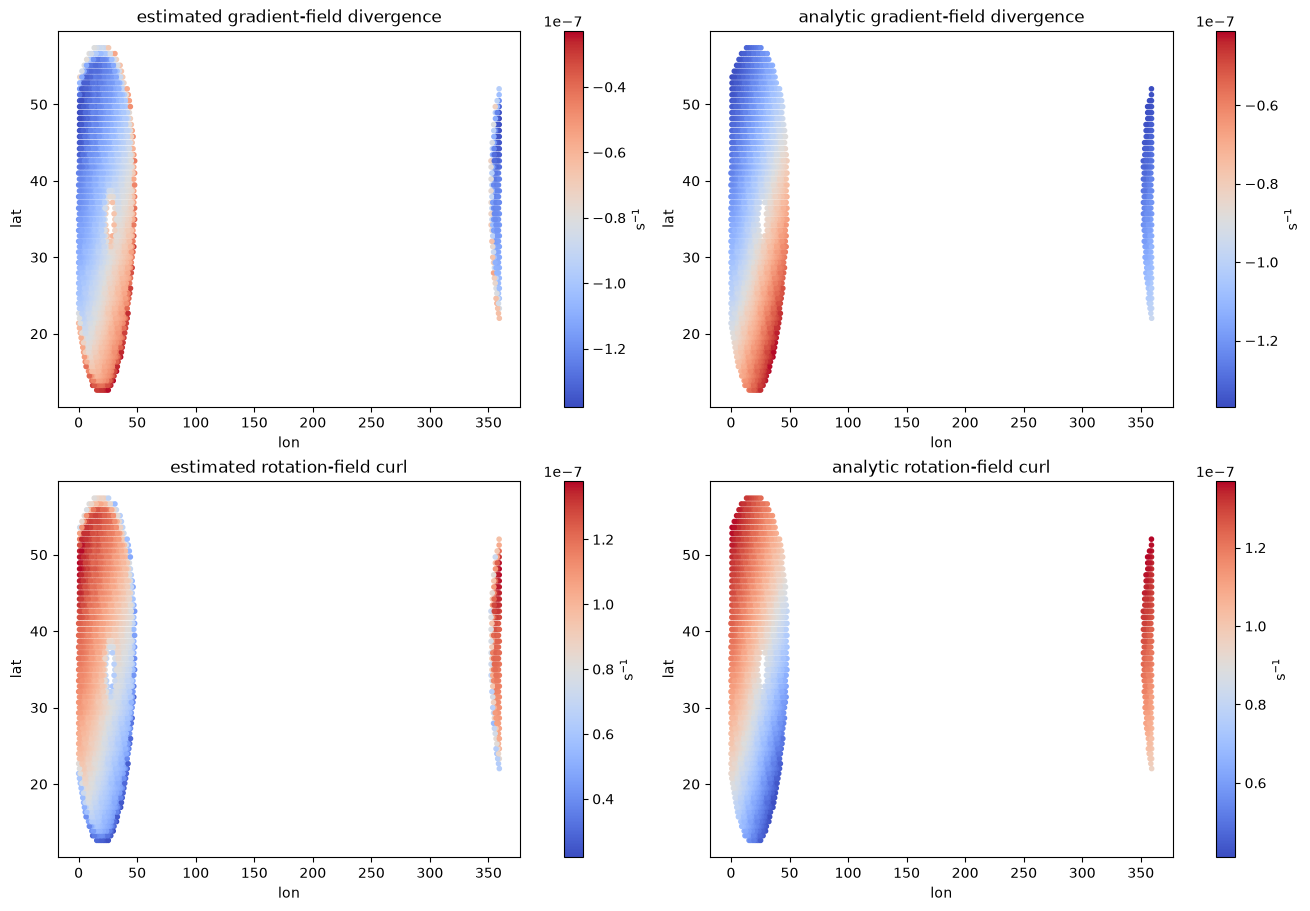

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
panels = (
    (gradient_mean[0], "estimated gradient-field divergence"),
    (truth_gradient[0], "analytic gradient-field divergence"),
    (rotation_mean[1], "estimated rotation-field curl"),
    (truth_rotation[1], "analytic rotation-field curl"),
)
for ax, (values, title) in zip(axes.ravel(), panels):
    artist = ax.scatter(lon, lat, c=values, s=9, cmap="coolwarm")
    ax.set_title(title)
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    fig.colorbar(artist, ax=ax, label="s$^{-1}$")

## Multiscale divergence and curl

The mixed analytic field is decomposed into three details plus one coarse map. A distinct `HealPixConv` derivative layer is built on each native grid.

In [6]:
velocity = torch.as_tensor(
    gradient_uv + 0.7 * rotation_uv, dtype=dtype, device=device
).unsqueeze(0)
decomp = HealPixDecomp(
    level=LEVEL, cell_ids=cell_ids, Jmax=3, ellipsoid="sphere",
    dtype=dtype, device=device,
)
velocity_pyramid = decomp(velocity)
multiscale = HealPixMultiScaleDivCurl(
    decomp,
    kernel_sz=3,
    n_gauges=2,
    gauge_type="projected_ref",
    singularity_lonlat=(20.0, -55.0),
    gauge_reduce="mean",
    radius_m=RADIUS_M,
)
diagnostics = multiscale(velocity_pyramid)

print("levels :", diagnostics.levels)
print("cells  :", [band.shape[-1] for band in diagnostics])
print("spacing:", [f"{value / 1000:.2f} km" for value in diagnostics.pixel_spacing_m])
assert diagnostics.levels == velocity_pyramid.levels
assert len(diagnostics) == len(velocity_pyramid)
for band, ids in zip(diagnostics, diagnostics.cell_ids):
    assert band.shape[-2] == 2
    assert band.shape[-1] == len(ids)
    assert torch.isfinite(band).all()
spacing_ratio = np.asarray(diagnostics.pixel_spacing_m[1:]) / np.asarray(diagnostics.pixel_spacing_m[:-1])
assert np.allclose(spacing_ratio, 2.0)

levels : (6, 5, 4, 3)
cells  : [1916, 509, 138, 42]
spacing: ['101.87 km', '203.74 km', '407.48 km', '814.95 km']


## Autograd

Both the multiscale decomposition and the fixed derivative convolutions remain connected to the input velocity.

In [7]:
learnable = velocity.detach().clone().requires_grad_(True)
learnable_diagnostics = multiscale(decomp(learnable))
loss = sum(band.square().mean() for band in learnable_diagnostics)
loss.backward()
assert learnable.grad is not None
assert torch.isfinite(learnable.grad).all()
print({"loss": loss.item(), "gradient_norm": learnable.grad.norm().item()})

{'loss': 3.574739817987335e-15, 'gradient_norm': 1.9517016573049165e-15}


## Interpretation

Each band now describes divergent and rotational motion over a different physical distance. The native stencil distance approximately doubles from one band to the next, while the `1 / pixel_spacing_m` normalisation keeps every result in the same physical unit. Cells close to mask boundaries should be interpreted with additional care because their convolution stencil is incomplete.